# Rencana Eksekusi Proyek AI: PSU091

## Tujuan Fase Eksekusi

Membangun model Deep Learning untuk optimasi menu makanan dengan batasan anggaran Rp10.000 menggunakan arsitektur TensorFlow tingkat lanjut.

### Pembagian Tugas Teknis (AI Engineer)

1. Tugas Yahdillah (Arsitektur & Core Logic)
Fokus pada pembangunan struktur utama dan logika sistem agar sesuai dengan standar penilaian Advanced Dicoding.

- Arsitektur Model: Merancang model menggunakan TensorFlow Functional API untuk fleksibilitas input nutrisi dan harga.

- Custom Training: Mengimplementasikan tf.GradientTape untuk proses update weights secara manual tanpa model.fit().

- Model Saving: Mengatur penyimpanan model ke format .keras agar siap digunakan oleh sistem Backend.

- Integrasi API: Menyelesaikan skrip FastAPI di folder /api sebagai jembatan antara model AI dan aplikasi web.

2. Tugas Silviyana (Data Preprocessing & Optimization)
Fokus pada persiapan data mentah dan memastikan model bekerja dengan performa terbaik.

- Data Wrangling: Mengolah dataset nutrisi dari tim Data Science ke dalam bentuk tensor yang siap diproses model.

- Feature Engineering: Melakukan scaling dan normalization pada fitur harga dan kalori bahan makanan.

- Hyperparameter Tuning: Melakukan eksperimen pada jumlah hidden layers, learning rate, dan batch size untuk meminimalkan Mean Absolute Error (MAE).

- Monitoring & Evaluasi: Membuat visualisasi grafik pelatihan (Loss & Accuracy) untuk memastikan model tidak mengalami overfitting.

In [1]:
!pip install tensorflow pandas numpy

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd

# Cek apakah sistem sudah siap
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
def build_model():
    # Mendefinisikan input: Anggaran dan Target Kalori
    inputs = tf.keras.Input(shape=(2,), name="input_layer")

    # Hidden Layers (Lapisan tersembunyi untuk belajar)
    x = tf.keras.layers.Dense(128, activation='relu')(inputs)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dense(32, activation='relu')(x)

    # Output Layer: Menghasilkan rekomendasi
    outputs = tf.keras.layers.Dense(1, name="output_layer")(x)

    # Menggabungkan menjadi satu model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

my_model = build_model()
my_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,753 (42.00 KB)

 Trainable params: 10,753 (42.00 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_object = tf.keras.losses.MeanSquaredError()

@tf.function
def train_step(data_input, labels):
    with tf.GradientTape() as tape:
        predictions = my_model(data_input, training=True)
        loss = loss_object(labels, predictions)
    gradients = tape.gradient(loss, my_model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, my_model.trainable_variables))

    return loss

In [5]:
# Membuat data percobaan (2 input: Budget & Kalori)
sample_input = tf.constant([[10000.0, 2000.0]], dtype=tf.float32)
sample_label = tf.constant([[1.0]], dtype=tf.float32) # Target nilai gizi/skor

# Memanggil fungsi yang sudah kamu buat tadi
current_loss = train_step(sample_input, sample_label)

# Menampilkan hasil error (loss) pertama
print(f"Hasil Loss Pertama: {current_loss.numpy()}")

Hasil Loss Pertama: 1171173.625


#Silvi

### load data

In [10]:
# Dataset nutrisi sesuai data dummy API
data = {
    'nama': ['Nasi Putih', 'Sayur Bayam Bening', 'Tempe Goreng',
             'Telur Rebus', 'Pisang Ambon',
             'Nasi Goreng', 'Tahu Rebus', 'Sup Ayam', 'Kentang Rebus', 'Jagung Rebus'],
    'harga': [1500, 2000, 1500, 2500, 2000,
              3000, 1000, 4000, 2000, 1500],
    'kalori': [130, 36, 170, 78, 89,
               250, 45, 120, 87, 96],
    'protein': [2.7, 2.9, 10.9, 12.4, 1.1,
                4.5, 7.2, 9.8, 2.1, 3.4],
    'skor_gizi': [0.60, 0.55, 0.75, 0.85, 0.50,
                  0.65, 0.58, 0.80, 0.62, 0.57]
}
df = pd.DataFrame(data)
print(df)

print("\nShape data:", df.shape)

                 nama  harga  kalori  protein  skor_gizi
0          Nasi Putih   1500     130      2.7       0.60
1  Sayur Bayam Bening   2000      36      2.9       0.55
2        Tempe Goreng   1500     170     10.9       0.75
3         Telur Rebus   2500      78     12.4       0.85
4        Pisang Ambon   2000      89      1.1       0.50
5         Nasi Goreng   3000     250      4.5       0.65
6          Tahu Rebus   1000      45      7.2       0.58
7            Sup Ayam   4000     120      9.8       0.80
8       Kentang Rebus   2000      87      2.1       0.62
9        Jagung Rebus   1500      96      3.4       0.57

Shape data: (10, 5)


In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df[['harga', 'kalori']])

X_tensor = tf.constant(X_scaled, dtype=tf.float32)
y_tensor = tf.constant(df[['skor_gizi']].values, dtype=tf.float32)

print("Data setelah normalisasi:")
print(pd.DataFrame(X_scaled, columns=['harga_scaled', 'kalori_scaled']))
print("\nShape X:", X_tensor.shape)
print("Shape y:", y_tensor.shape)

Data setelah normalisasi:
   harga_scaled  kalori_scaled
0      0.166667       0.439252
1      0.333333       0.000000
2      0.166667       0.626168
3      0.500000       0.196262
4      0.333333       0.247664
5      0.666667       1.000000
6      0.000000       0.042056
7      1.000000       0.392523
8      0.333333       0.238318
9      0.166667       0.280374

Shape X: (10, 2)
Shape y: (10, 1)


In [12]:
import itertools

learning_rates = [0.001, 0.01]
hidden_units = [64, 128]
batch_sizes = [2, 4]

results = []

for lr, units, batch in itertools.product(learning_rates, hidden_units, batch_sizes):
    inputs = tf.keras.Input(shape=(2,))
    x = tf.keras.layers.Dense(units, activation='relu')(inputs)
    x = tf.keras.layers.Dense(units // 2, activation='relu')(x)
    outputs = tf.keras.layers.Dense(1)(x)
    model = tf.keras.Model(inputs, outputs)

    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mae', metrics=['mae'])
    history = model.fit(X_tensor, y_tensor, epochs=50, batch_size=batch, verbose=0)

    final_mae = history.history['mae'][-1]
    results.append({'lr': lr, 'units': units, 'batch': batch, 'MAE': final_mae})
    print(f"lr={lr}, units={units}, batch={batch} → MAE: {final_mae:.4f}")

results_df = pd.DataFrame(results)
print("\nKombinasi terbaik:")
print(results_df.sort_values('MAE').head(1))

lr=0.001, units=64, batch=2 → MAE: 0.0438
lr=0.001, units=64, batch=4 → MAE: 0.0580
lr=0.001, units=128, batch=2 → MAE: 0.0520
lr=0.001, units=128, batch=4 → MAE: 0.0537
lr=0.01, units=64, batch=2 → MAE: 0.0887
lr=0.01, units=64, batch=4 → MAE: 0.0714
lr=0.01, units=128, batch=2 → MAE: 0.0708
lr=0.01, units=128, batch=4 → MAE: 0.0592

Kombinasi terbaik:
      lr  units  batch       MAE
0  0.001     64      2  0.043758


Hyperparameter terbaik → lr=0.001, units=64, batch=2
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.5997 - mae: 0.5997 - val_loss: 0.5197 - val_mae: 0.5197
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.5336 - mae: 0.5336 - val_loss: 0.4700 - val_mae: 0.4700
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.4713 - mae: 0.4713 - val_loss: 0.4170 - val_mae: 0.4170
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.3993 - mae: 0.3993 - val_loss: 0.3552 - val_mae: 0.3552
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.3152 - mae: 0.3152 - val_loss: 0.2855 - val_mae: 0.2855
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2368 - mae: 0.2368 - val_loss: 0.2204 - val_mae: 0.2204
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.2173 - mae: 0.2173 - val_loss: 0.1578 - val_mae: 0.1578
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1824 - mae: 0.1824 - val_loss: 0.1161 - val_mae: 0.1161
Epoch 9/100
4/4 ━━━

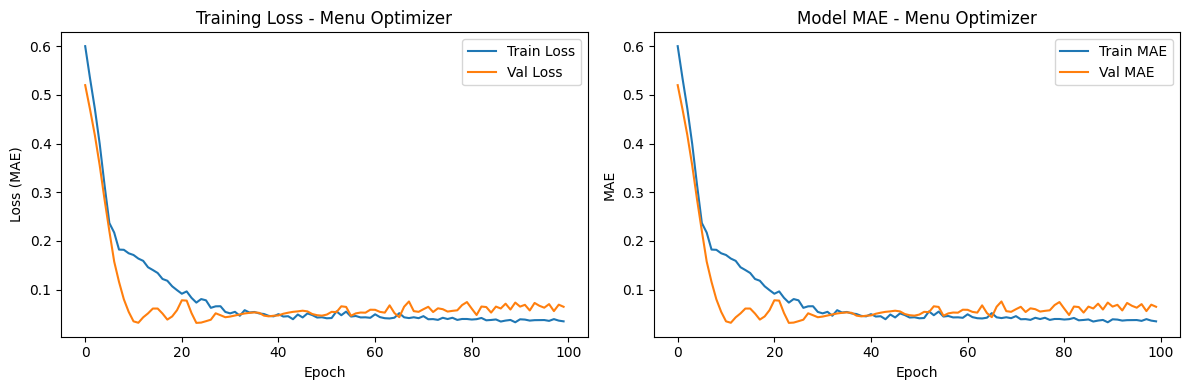


Final Train MAE : 0.0352
Final Val MAE   : 0.0650


In [13]:
import matplotlib.pyplot as plt

# Ambil hyperparameter terbaik
best = results_df.sort_values('MAE').iloc[0]
print(f"Hyperparameter terbaik → lr={best['lr']}, units={int(best['units'])}, batch={int(best['batch'])}")

# Build ulang model terbaik
inputs = tf.keras.Input(shape=(2,))
x = tf.keras.layers.Dense(int(best['units']), activation='relu')(inputs)
x = tf.keras.layers.Dense(int(best['units']) // 2, activation='relu')(x)
outputs = tf.keras.layers.Dense(1)(x)
best_model = tf.keras.Model(inputs, outputs)

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(best['lr']),
    loss='mae',
    metrics=['mae']
)

# Train dengan validation split
history = best_model.fit(
    X_tensor, y_tensor,
    epochs=100,
    batch_size=int(best['batch']),
    validation_split=0.2,
    verbose=1
)

# Plot Loss & MAE
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training Loss - Menu Optimizer')
plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Model MAE - Menu Optimizer')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

print(f"\nFinal Train MAE : {history.history['mae'][-1]:.4f}")
print(f"Final Val MAE   : {history.history['val_mae'][-1]:.4f}")